## House Price Category Prediction Using Machine Learning Classification Algorithms

In [1]:
# Import basic libraries
import pandas as pd
import numpy as np

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Import classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

#### Loading the dataset

In [2]:
# Load the training dataset
df = pd.read_csv("train.csv")

# Display first five rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

#### Checking the target column

In [4]:
# Check SalePrice statistics
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

#### Creating price categories

In [5]:
# Create three price categories: Low, Medium, High
df["PriceCategory"] = pd.qcut(
    df["SalePrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Check category counts
df["PriceCategory"].value_counts()

PriceCategory
Medium    490
Low       487
High      483
Name: count, dtype: int64

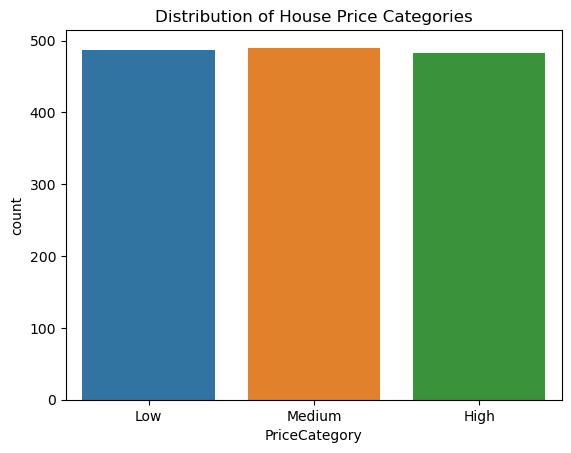

In [6]:
# checking visually
sns.countplot(x="PriceCategory", data=df)
plt.title("Distribution of House Price Categories")
plt.show()

#### Droping unnecessaty columns

In [7]:
# Drop original target and ID column
X = df.drop(["SalePrice", "PriceCategory", "Id"], axis=1)

# New classification target
y = df["PriceCategory"]

#### Handling missing values

In [8]:
# Separate numerical and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 36
Number of categorical columns: 43


In [9]:
## filling missing values

# Fill missing numerical values with median
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Fill missing categorical values with mode
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [10]:
# check for missing values
X.isnull().sum().sum()

0

#### Encode categorical variables

In [11]:
# Convert categorical columns into numeric dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [12]:
X_encoded.shape

(1460, 244)

#### Spliting train and test data

In [13]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1168, 244)
Testing data shape: (292, 244)


#### Scaling the data

In [14]:
# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)